In [1]:
# %matplotlib inline
%matplotlib widget
%config InlineBackend.figure_format = 'retina'

In [ ]:
import random
from collections import Counter, defaultdict
from typing import TypedDict

import matplotlib.pyplot as plt
import pandas as pd
import pyspiel
import torch
import torch.nn as nn
from torch.distributions import Categorical
from tqdm.auto import trange

from cleptoninja import Auction, CleptoNinjaState, Phase
from cleptoninja import register_game as register_cleptoninja_game
from player import GreedyPlayer, Player, RandomPlayer

In [ ]:
# TODO: Model players as a dataclass, hold their hands there. adapt rest of code
# TODO: Have auction resolution whithin dataclass. Query from game for card redistribution
# TODO: Change if phase ... for pattern matching everywhere

In [ ]:
register_cleptoninja_game()

## Train


In [ ]:
def flatten(xs):
    out = []
    stack = [xs]
    while stack:
        cur = stack.pop()
        if isinstance(cur, list):
            stack.extend(reversed(cur))
        else:
            out.append(cur)
    return out

In [ ]:
def onehot(index, size, offset=0):
    res = [0] * size
    if index is not None:
        res[index + offset] = 1

    return res


def multihot(cards, size, offset=0):
    res = [0] * size
    for index, count in Counter(cards).items():
        res[index + offset] = count

    return res


def encode_auction(
    auction: Auction, player_index: int, player_count: int, max_card_value: int
) -> list[int | float]:
    auctioneer_onehot = onehot(auction.auctioneer, player_count)
    show_offer_private = int(
        auction.auctioneer == player_index or auction.all_bids_received
    )
    offer = [
        onehot(auction.offer_public, max_card_value, offset=-1),
        onehot(
            auction.offer_private if show_offer_private else None,
            max_card_value,
            offset=-1,
        ),
    ]

    missing_bids_count = auction.expected_bid_count - len(auction.bids)
    is_bid_pressent = [1] * len(auction.bids) + [0] * missing_bids_count
    is_bid_visible = [
        int(bid.bidder == player_index or auction.all_bids_received)
        for bid in auction.bids
    ] + [0] * missing_bids_count
    bids_cards = [
        bid.cards if show_bid else []
        for show_bid, bid in zip(is_bid_visible, auction.bids)
    ] + [[]] * missing_bids_count
    bids_multihot = [multihot(cards, max_card_value, offset=-1) for cards in bids_cards]
    bid_values = [sum(cards) / (2 * max_card_value) for cards in bids_cards]

    encoded = flatten(
        [
            auctioneer_onehot,
            show_offer_private,
            offer,
            auction.expected_bid_count,
            missing_bids_count / (player_count - 1),
            bids_multihot,
            bid_values,
            is_bid_pressent,
            is_bid_visible,
        ]
    )
    return encoded


def empty_encoded_auction(player_count, max_card_value) -> list[int | float]:
    expected_bid_count = player_count - 1
    bids_multihot = [
        multihot([], max_card_value, offset=-1) for _ in range(expected_bid_count)
    ]

    encoded = flatten(
        [
            [0] * player_count,  # auctioneer_onehot
            0,  # show_offer_private
            [[0] * max_card_value, [0] * max_card_value],  # offer
            expected_bid_count,
            1,  # missing_bids_ration
            bids_multihot,
            [0] * expected_bid_count,  # bid_values
            [0] * expected_bid_count,  # is_bid_present
            [0] * expected_bid_count,  # is_bid_visible
        ]
    )
    return encoded


def encode_observation(state: CleptoNinjaState, player_index: int) -> list[int | float]:
    player_count = len(state._hands)
    max_card_value = state.max_card

    phase_onehot = onehot(0 if state._phase == Phase.OFFER else 1, size=2)
    round_one_hot = onehot(state._round, player_count)
    player_onehot = onehot(player_index, player_count)
    hand_multihot = multihot(state._hands[player_index], max_card_value, offset=-1)

    auctions = [
        encode_auction(auction, player_index, player_count, max_card_value)
        for auction in state._auctions
    ]
    missing_auctions_count = player_count - len(auctions)
    auctions += [
        empty_encoded_auction(player_count, max_card_value)
        for _ in range(missing_auctions_count)
    ]

    encoded = (
        phase_onehot
        + round_one_hot
        + player_onehot
        + hand_multihot
        + flatten(auctions)
        + [missing_auctions_count / player_count]
    )

    return encoded

In [ ]:
def legal_action_mask(state: CleptoNinjaState, player_index: int):
    size = 2 * state.max_card**2
    mask = [0] * size
    for a in state._legal_actions(player_index):
        mask[a] = 1
    return mask

In [ ]:
class ActorCriticModel(nn.Module):
    """
    Shared actor–critic network.

    Given an observation tensor, outputs:
    - action logits for a discrete policy
    - a scalar state-value estimate V(s)

    Used by PPO as a policy–value (actor–critic) model with a shared backbone.
    """

    def __init__(self, obs_dim: int, num_actions: int, hidden: int = 256):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.actor = nn.Linear(hidden, num_actions)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, obs: torch.Tensor):
        x = self.trunk(obs)
        return self.actor(x), self.critic(x).squeeze(-1)


def masked_categorical(logits: torch.Tensor, mask: torch.Tensor) -> Categorical:
    """
    Create a categorical distribution with invalid actions masked out.

    Logits corresponding to mask == False are assigned a large negative value
    so they are never sampled and have zero probability.
    """
    masked_logits = logits.clone()
    masked_logits[~mask] = -1e9
    return Categorical(logits=masked_logits)


@torch.no_grad()
def select_action(model, observations, mask):
    """
    Sample a legal action from the policy and return PPO-relevant quantities.

    Returns:
    - action (int): sampled action index
    - logprob (float): log π(a|s) of the sampled action
    - entropy (float): policy entropy at the state
    - value (float): critic value estimate V(s)
    """
    logits, value = model(observations)
    dist = masked_categorical(logits, mask)
    action = dist.sample()
    return (
        int(action.item()),
        float(dist.log_prob(action).item()),
        float(dist.entropy().item()),
        float(value.item()),
    )

In [ ]:
from typing import NotRequired


class Trajectory(TypedDict):
    observation: torch.Tensor
    mask: torch.Tensor
    action: int
    logprob: float
    value: float
    player: int
    reward: float
    done: bool
    advantage: NotRequired[float]
    return_: NotRequired[float]


def collect_episode(game, model, device="cpu"):
    """
    Defaults device to CPU to avoid CPU-GPU transfers. Lots of tensors being
    created and moved around without computing that takes advantadge of GPU.
    """
    state = game.new_initial_state()

    trajectories: list[Trajectory] = []
    step_indices_by_player = {
        player_idx: [] for player_idx in range(game.num_players())
    }

    while not state.is_terminal():
        player = state.current_player()

        observation = torch.tensor(
            encode_observation(state, player), dtype=torch.float32, device=device
        )
        mask = torch.tensor(
            legal_action_mask(state, player), dtype=torch.bool, device=device
        )

        action, logprob, _, value = select_action(model, observation, mask)

        trajectories.append(
            Trajectory(
                observation=observation,
                mask=mask,
                action=action,
                logprob=logprob,
                value=value,
                player=player,
                reward=0.0,
                done=False,
            )
        )
        step_indices_by_player[player].append(len(trajectories) - 1)

        state._apply_action(action)

    # terminal rewards
    returns = state.returns()
    for player, player_steps_indices in step_indices_by_player.items():
        last_player_step = player_steps_indices[-1]
        trajectories[last_player_step]["reward"] = returns[player]
        trajectories[last_player_step]["done"] = True

    return trajectories

In [ ]:
def add_gae(
    trajectories: list[Trajectory], gamma: float = 1.0, lam: float = 0.95
) -> list[Trajectory]:
    """
    Compute Generalized Advantage Estimation (GAE) for a set of trajectories.

    GAE assigns a learning signal (the advantage) to each decision step,
    indicating whether the chosen action led to a better or worse outcome
    than the value function predicted.

    Parameters
    ----------
    trajectories : ...
    gamma : Discount factor. 1.0 for undiscounted.
    lam : Smoothing parametere. Higher values propagate rewards further but add noise.
    """
    # group indices by player in chronological order
    step_indices_by_player = defaultdict(list)
    for idx, trajectory in enumerate(trajectories):
        step_indices_by_player[trajectory["player"]].append(idx)

    for player_step_indices in step_indices_by_player.values():
        advantage = 0.0
        next_value = 0.0  # terminal bootstrap

        for k in reversed(range(len(player_step_indices))):
            global_step_index = player_step_indices[k]
            reward = trajectories[global_step_index]["reward"]
            done = trajectories[global_step_index]["done"]
            value = trajectories[global_step_index]["value"]

            bootstrap = 0.0 if done else next_value
            delta = reward + gamma * bootstrap - value

            advantage = delta + gamma * lam * (0.0 if done else advantage)

            trajectories[global_step_index]["advantage"] = advantage
            trajectories[global_step_index]["return"] = advantage + value

            next_value = value

    return trajectories

In [ ]:
def ppo_update(
    model,
    optimizer,
    batch,
    clip_eps: float = 0.2,
    value_loss_coef: float = 0.5,
    entropy_loss_coef: float = 0.01,
):
    """
    Proximal Policy Optimization (PPO) update.


    Parameters
    ----------
    model : ...
    optimizer : ...
    batch : ...
    clip_eps : PPO clipping parameter ε.
    value_loss_coef : Weight of the value-function in the loss.
    entropy_loss_coef : Weight of the entropy in the loss.
    """
    observations = batch["observations"]  # [B, obs_dim]
    mask = batch["mask"]  # [B, num_actions]
    actions = batch["actions"]  # [B]
    old_logprobs = batch["old_logprobs"]  # [B]
    advantages = batch["advantages"]  # [B]
    returns = batch["returns"]  # [B]

    logits, values = model(observations)
    dist = masked_categorical(logits, mask)

    logprobs = dist.log_prob(actions)
    ratio = torch.exp(logprobs - old_logprobs)

    # Policy loss component
    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
    policy_loss = -(torch.min(surr1, surr2)).mean()

    # Value loss component
    value_loss = 0.5 * (returns - values).pow(2).mean()

    # Entropy loss component
    entropy = dist.entropy().mean()

    loss = policy_loss + value_loss * value_loss_coef - entropy * entropy_loss_coef

    with torch.no_grad():
        log_ratio = logprobs - old_logprobs
        approx_kl = (torch.exp(log_ratio) - 1 - log_ratio).mean()  # common PPO approx
        clip_fraction = (torch.abs(ratio - 1.0) > clip_eps).float().mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "policy_loss": policy_loss.item(),
        "value_loss": value_loss.item(),
        "entropy": entropy.item(),
        "approx_kl": approx_kl.item(),
        "clip_fraction": clip_fraction.item(),
    }

In [ ]:
def make_batch(trajectories, device="cpu"):
    observations = torch.stack([t["observation"] for t in trajectories]).to(device)
    masks = torch.stack([t["mask"] for t in trajectories]).to(device)

    actions = torch.tensor(
        [t["action"] for t in trajectories], dtype=torch.long, device=device
    )
    old_logprobs = torch.tensor(
        [t["logprob"] for t in trajectories], dtype=torch.float32, device=device
    )

    advantages = torch.tensor(
        [t["advantage"] for t in trajectories], dtype=torch.float32, device=device
    )
    returns = torch.tensor(
        [t["return"] for t in trajectories], dtype=torch.float32, device=device
    )

    # normalize advantages
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return {
        "observations": observations,
        "mask": masks,
        "actions": actions,
        "old_logprobs": old_logprobs,
        "advantages": advantages,
        "returns": returns,
    }


def iterate_minibatches(batch, minibatch_size, shuffle=True):
    B = batch["observations"].shape[0]
    idx = torch.arange(B, device=batch["observations"].device)
    if shuffle:
        idx = idx[torch.randperm(B, device=idx.device)]

    for start in range(0, B, minibatch_size):
        mb_idx = idx[start : start + minibatch_size]
        yield {k: v[mb_idx] for k, v in batch.items()}

In [ ]:
training_device = "cpu"  # "mps"
episodes_per_update = 128  # 64
num_updates = 500  # ≈ 500 * 64 ≈ 32k games total
ppo_epochs = 4
minibatch_size = 256
import copy
import json
from pathlib import Path
from statistics import mean

game = pyspiel.load_game("clepto_ninja")
state = game.new_initial_state()
model = ActorCriticModel(
    obs_dim=len(encode_observation(state, player_index=0)),
    num_actions=2 * (state.max_card**2),
).to(training_device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, eps=1e-5)

training_metrics = []
json_path = Path("metrics.json")
json_path.write_text("[]")
checkpoints = []

for update in trange(num_updates, desc="Update"):
    rollout_model = (
        copy.deepcopy(model).to("cpu").eval()
    )  # trajectory collection happens in CPU for performance

    all_trajectories = []
    for _ in range(episodes_per_update):
        trajectories = collect_episode(game, rollout_model, device="cpu")
        trajectories = add_gae(trajectories)
        all_trajectories.extend(trajectories)

    batch = make_batch(
        all_trajectories, device=training_device
    )  # stacks tensors + advantage norm
    batch_metrics = []
    for epoch in range(ppo_epochs):
        for minibatch in iterate_minibatches(batch, minibatch_size):
            metrics = ppo_update(
                model, optimizer, minibatch, entropy_loss_coef=0.002, clip_eps=0.1
            )
            batch_metrics.append(metrics)

    checkpoints.append({k: v.cpu().clone() for k, v in model.state_dict().items()})

    batch_metrics = {k: mean(m[k] for m in batch_metrics) for k in batch_metrics[0]}
    data = json.loads(json_path.read_text())
    data.append(batch_metrics)
    json_path.write_text(json.dumps(data))

Update:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
class ActorCriticPlayer(Player):
    def __init__(self, model, player_tag=None):
        self.model = model
        self.player_tag = player_tag

    @property
    def name(self):
        return f"{super().name}_tag:{self.player_tag}"

    def action(self, state, player_id):
        observation = torch.tensor(
            encode_observation(state, player_id), dtype=torch.float32, device="cpu"
        )
        mask = torch.tensor(
            legal_action_mask(state, player_id), dtype=torch.bool, device="cpu"
        )
        action, *_ = select_action(self.model, observation, mask)
        return action

    # TODO: delete __str__ and __repr__, already in Player base class
    def __str__(self):
        return self.name

    def __repr__(self) -> str:
        return self.__str__()

In [ ]:
def trained_player_from_checkpoint(checkpoint, player_tag):
    model = ActorCriticModel(
        obs_dim=len(encode_observation(state, player_index=0)),
        num_actions=2 * (state.max_card**2),
    )
    model.load_state_dict(checkpoint)
    model.eval()
    player = ActorCriticPlayer(model, player_tag=player_tag)
    return player

In [ ]:
trained_player_from_checkpoint(checkpoints[0], player_tag=222).action(state, 0)

35

In [ ]:
def run_game(game, players: list[Player], debug=False):
    state = game.new_initial_state()
    while not state.is_terminal():
        player = state.current_player()
        action = players[player].action(state, player)
        state.apply_action(action)

        if debug:
            print(state)
            print()

    return state

## Evaluate


### All vs all (trained and euristics)



In [ ]:
SIMULATION_COUNT = 100_000
models_from_pool_count = 10

sampled_iteration_idexes = [
    round(i * (len(checkpoints) - 1) / (models_from_pool_count - 1))
    for i in range(models_from_pool_count)
]
trained_players = []
for iteration_index in sampled_iteration_idexes:
    checkpoint = checkpoints[iteration_index]
    model = ActorCriticModel(
        obs_dim=len(encode_observation(state, player_index=0)),
        num_actions=2 * (state.max_card**2),
    )
    model.load_state_dict(checkpoint)
    model.eval()
    player = ActorCriticPlayer(model, player_tag=iteration_index)
    trained_players.append(player)

ALL_MACHINE_PLAYERS = [GreedyPlayer(), RandomPlayer()] + trained_players

player_count = 4
rows = []
for simulation_idex in trange(SIMULATION_COUNT):
    players = [random.choice(ALL_MACHINE_PLAYERS)] * player_count
    end_state = run_game(game, players)
    rows.append(end_state.returns() + [p.name for p in players])

    if simulation_idex % 1000 == 0:
        game_results = pd.DataFrame(
            rows,
            columns=[f"payout_{i}" for i in range(player_count)]
            + [f"player_{i}" for i in range(player_count)],
        )
        game_results.to_csv("game_results_partial.csv", index=False)

game_results = pd.DataFrame(
    rows,
    columns=[f"payout_{i}" for i in range(player_count)]
    + [f"player_{i}" for i in range(player_count)],
)

  0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
def plot_game_payouts(game_results, max_plotted_games=1_000):
    game_results = (
        game_results
        if len(game_results) < max_plotted_games
        else game_results.sample(max_plotted_games).sort_index()
    )

    player_cols = [col for col in game_results if col.startswith("player_")]
    player_count = len(player_cols)
    _, ax = plt.subplots(figsize=(18, 3))

    # Build a stable color mapping for policies
    policies = pd.unique(game_results[player_cols].values.ravel())
    cmap = dict(zip(policies, plt.cm.tab10.colors[: len(policies)]))

    for i in range(player_count):
        ax.scatter(
            game_results.index,
            game_results[f"payout_{i}"],
            # c=game_results[f"player_{i}"].map(cmap),
            s=20,
        )

    ax.set_xlabel("run")
    ax.set_ylabel("payout")
    ax.set_title(f"Player payouts ({len(game_results)} simulations)")

    # Optional legend
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=p)
        for p, c in cmap.items()
    ]
    ax.legend(
        handles=handles, title="player", bbox_to_anchor=(1.02, 1), loc="upper left"
    )

    plt.tight_layout()
    plt.show()

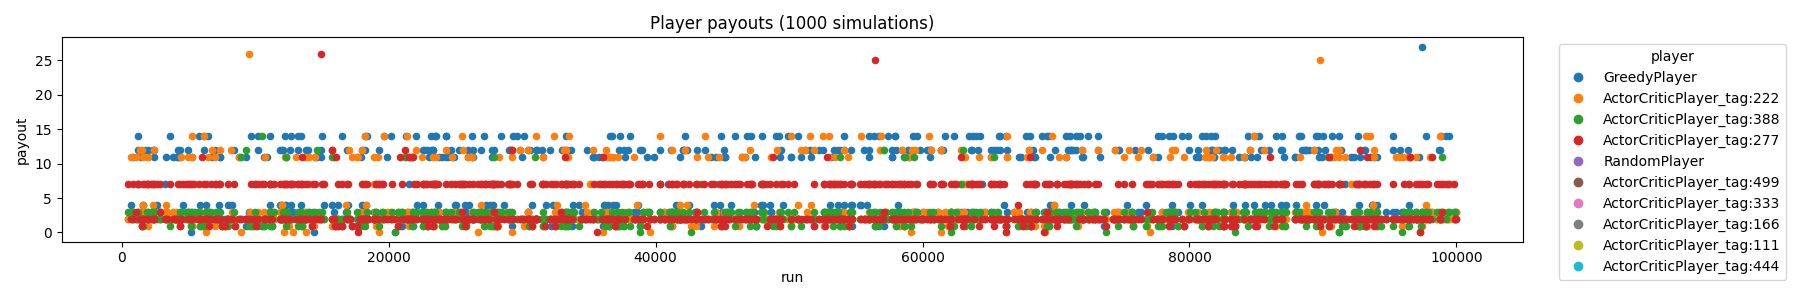

In [ ]:
plot_game_payouts(game_results, max_plotted_games=1000)

In [ ]:
def player_payout_stats(game_results):
    player_cols = [col for col in game_results if col.startswith("player_")]
    payout_cols = [col for col in game_results if col.startswith("payout_")]
    player_count = len(player_cols)

    long_df = pd.concat(
        [
            game_results[[payout_cols[i], player_cols[i]]].rename(
                columns={payout_cols[i]: "payout", player_cols[i]: "player"}
            )
            for i in range(player_count)
        ],
        ignore_index=True,
    )

    summary = (
        long_df.groupby("player")["payout"]
        .agg(
            min="min",
            q1=lambda x: x.quantile(0.25),
            median="median",
            mean="mean",
            q3=lambda x: x.quantile(0.75),
            max="max",
        )
        .reset_index()
    )

    return summary

### Trained player evolution

In [ ]:
player_payout_stats(game_results).sort_values("player", ascending=True)

,player,min,q1,median,mean,q3,max
0,ActorCriticPlayer_tag:0,0.0,1.0,2.0,3.128127,3.0,32.0
1,ActorCriticPlayer_tag:111,0.0,2.0,2.0,4.023305,3.0,14.0
2,ActorCriticPlayer_tag:166,0.0,2.0,2.0,4.024555,3.0,14.0
3,ActorCriticPlayer_tag:222,0.0,2.0,2.0,4.003468,3.0,14.0
4,ActorCriticPlayer_tag:277,0.0,2.0,2.0,4.090167,3.0,14.0
5,ActorCriticPlayer_tag:333,0.0,2.0,2.0,4.356989,7.0,14.0
6,ActorCriticPlayer_tag:388,0.0,2.0,3.0,5.056308,7.0,14.0
7,ActorCriticPlayer_tag:444,0.0,2.0,3.0,5.154633,7.0,14.0
8,ActorCriticPlayer_tag:499,0.0,2.0,3.0,4.901068,7.0,14.0
9,ActorCriticPlayer_tag:55,0.0,2.0,2.0,3.436447,3.0,32.0


### Per seat payouts


In [ ]:
game_results[[c for c in game_results.columns if c.startswith("payout_")]].describe()

,payout_0,payout_1,payout_2,payout_3
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.046220,3.892780,2.291020,3.940040
std,4.808471,3.812869,1.482238,2.655315
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,3.000000,2.000000,2.000000,2.000000
75%,11.000000,3.000000,2.000000,7.000000
max,32.000000,32.000000,32.000000,26.000000


### Evaluate player trained at different steps against euristics

Take a player from step n, create games where it is the only trained one playing
against fixed euristics. Seats rotate.

For completeness, have an evaluation with only trained players.


In [ ]:
SIMULATION_COUNT = 10_000

game_results = []
checkpoint_indexes = [
    0,
    len(checkpoints) // 4,
    (len(checkpoints) * 3) // 4,
    len(checkpoints) - 1,
]
for checkpoint_index in checkpoint_indexes:
    checkpoint = checkpoints[checkpoint_index]
    trained_player = trained_player_from_checkpoint(
        checkpoint, player_tag=checkpoint_index
    )
    players = [trained_player, GreedyPlayer(), GreedyPlayer(), RandomPlayer()]
    players = random.sample(players, 4)

    player_count = len(players)
    rows = []
    for simulation_idex in trange(SIMULATION_COUNT):
        end_state = run_game(game, players)
        rows.append(end_state.returns() + [p.name for p in players])

    game_results.append(
        {
            "checkpoint_index": checkpoint_index,
            "results": pd.DataFrame(
                rows,
                columns=[f"payout_{i}" for i in range(player_count)]
                + [f"player_{i}" for i in range(player_count)],
            ),
        }
    )


players = [
    trained_player_from_checkpoint(checkpoints[i], i) for i in checkpoint_indexes
]
players = random.sample(players, 4)
player_count = len(players)
rows = []
for simulation_idex in trange(SIMULATION_COUNT):
    end_state = run_game(game, players)
    rows.append(end_state.returns() + [p.name for p in players])

game_results.append(
    {
        "checkpoint_index": "all_trained",
        "results": pd.DataFrame(
            rows,
            columns=[f"payout_{i}" for i in range(player_count)]
            + [f"player_{i}" for i in range(player_count)],
        ),
    }
)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
for game_result in game_results:
    print(f"Results for checkpoint index: {game_result['checkpoint_index']}")
    display(player_payout_stats(game_result["results"]))

Results for checkpoint index: 0


,player,min,q1,median,mean,q3,max
0,ActorCriticPlayer_tag:0,0.0,2.0,2.0,4.1263,3.0,50.0
1,GreedyPlayer,0.0,2.0,2.0,3.1895,3.0,26.0
2,RandomPlayer,0.0,1.0,2.0,3.5777,3.0,32.0


Results for checkpoint index: 125


,player,min,q1,median,mean,q3,max
0,ActorCriticPlayer_tag:125,0.0,2.0,11.0,9.3085,14.0,32.0
1,GreedyPlayer,1.0,2.0,2.0,3.9383,7.0,14.0
2,RandomPlayer,0.0,1.0,2.0,2.2004,2.0,32.0


Results for checkpoint index: 375


,player,min,q1,median,mean,q3,max
0,ActorCriticPlayer_tag:375,0.0,2.0,3.0,6.0779,11.0,50.0
1,GreedyPlayer,1.0,2.0,2.0,2.9284,3.0,32.0
2,RandomPlayer,0.0,2.0,3.0,5.2791,7.0,27.0


Results for checkpoint index: 499


,player,min,q1,median,mean,q3,max
0,ActorCriticPlayer_tag:499,1.0,3.0,11.0,9.5980,12.0,32.0
1,GreedyPlayer,1.0,2.0,2.0,2.1353,2.0,14.0
2,RandomPlayer,0.0,1.0,2.0,1.7596,2.0,12.0


Results for checkpoint index: all_trained


,player,min,q1,median,mean,q3,max
0,ActorCriticPlayer_tag:0,0.0,1.0,2.0,1.5904,2.0,12.0
1,ActorCriticPlayer_tag:125,0.0,2.0,3.0,4.7545,4.0,32.0
2,ActorCriticPlayer_tag:375,0.0,2.0,3.0,5.1701,11.0,14.0
3,ActorCriticPlayer_tag:499,0.0,2.0,2.0,2.1652,2.0,11.0
